# 02b. Fahy & Gardonio's box, driven

The box of `02_cavity_plate_coupled_FG`, cut finer and pushed: 1 N at the
centre of the plate. The direct coupled solve costs about 3 s a line on
this mesh, so it is run at **ten lines only** — a demonstration, not a
sweep — and the continuous curves come from the two reduced models, which
run the whole band in seconds. The ten direct points are what they are read
against.

| | |
|---|---|
| cavity | 0.414 x 0.314 x 0.360 m, air, five hard walls |
| plate | 1 mm aluminium, clamped, on the top face |
| mesh | 32 x 24 x 16 `CHEXA8` + 32 x 24 `CQUAD4F`, conforming |
| drive | 1 N along z at the centre of the plate, eta_s = 0.02 |
| methods | ten direct lines, coupled-modal and CMS across the band |
| read | displacement at the drive, cavity average pressure |

What changes from 02: a finer mesh (theirs stops resolving the plate well
below 1000 Hz) and a point force. Geometry, material and walls are the same.


---
## 1. The run

`from pycafe import *` is the whole import. The plate is written out because
the book's modulus is not pyCAFE's default and its Poisson ratio is not
quoted (0.33 assumed).

`DF` is the grid the two reduced models are swept on; `N_PROBE` is how many
of those lines the direct solver is actually run at. The direct cost is one
factorization of a complex unsymmetric matrix per line, about 3 s on
~18 000 unknowns: ten lines is half a minute, the whole grid close to half
an hour.


In [1]:
%matplotlib widget
# every figure below is a live canvas that can be turned with the mouse
# (needs ipympl); drop this line for flat pictures instead.

import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))                 # run from examples/

import numpy as np
import matplotlib.pyplot as plt

from pycafe import *          # the whole API: models, questions, solvers, plots

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

ANALYSIS = "vibroacoustic"                 # acoustic and structure, coupled
FLUID = AIR

# Fahy & Gardonio's aluminium: rho = 2700 kg/m3, E = 7.1e10 N/m2, h = 1 mm,
# clamped on all four edges. nu is not given in the example; 0.33 is used.
STRUCTURE = Structure(t=1.0e-3, E=7.1e10, nu=0.33, rho_s=2700.0,
                      name="aluminium", support="clamped")

F_MAX = 1000.0       # the top of the sweep, and what the mesh is checked against
F_MIN = 20.0         # below the first plate mode
DF = 2.0             # the grid the reduced models are swept on: 491 lines
N_PROBE = 10         # how many of those lines the direct solver is run at
FORCE = 1.0          # N, normal to the plate, at its centre
ETA_S = 0.02         # structural loss factor; the air carries no damping

N_MODES = 50         # coupled modes, to mark the lines the sweep should show

frequencies = np.arange(F_MIN, F_MAX + DF, DF)
RHO0, C0 = FLUID.rho0, FLUID.c0

print(f"{ANALYSIS} run in {FLUID.name}, c0 = {C0:.0f} m/s")
print(f"plate: {STRUCTURE.name}, {STRUCTURE.t * 1e3:.1f} mm, "
      f"{STRUCTURE.support}, E = {STRUCTURE.E:.3g} Pa, nu = {STRUCTURE.nu}, "
      f"rho = {STRUCTURE.rho_s:.0f} kg/m3")
print(f"       D = {STRUCTURE.D:.3f} N m, "
      f"mass = {STRUCTURE.rho_s * STRUCTURE.t:.2f} kg/m2")
print(f"sweep: {F_MIN:.0f} to {F_MAX:.0f} Hz in {DF:.1f} Hz steps, "
      f"{frequencies.size} lines reduced, {N_PROBE} of them direct")
print(f"drive: {FORCE:.0f} N at the centre of the plate, eta_s = {ETA_S}")

vibroacoustic run in air, c0 = 343 m/s
plate: aluminium, 1.0 mm, clamped, E = 7.1e+10 Pa, nu = 0.33, rho = 2700 kg/m3
       D = 6.640 N m, mass = 2.70 kg/m2
sweep: 20 to 1000 Hz in 2.0 Hz steps, 491 lines reduced, 10 of them direct
drive: 1 N at the centre of the plate, eta_s = 0.02


---
## 2. The geometry

One file, named here: `Library/cavity_plate_FG_directresponse.msh`. Same box
as 02, conforming interface, twice the elements per plate side and through
the depth.

The plate sets the mesh, not the air: bending waves are much shorter than
sound at the same frequency. Element counts are pinned in
`Library/make_library.py` for about eight elements per bending wavelength.

MeshFile -> cavity_plate_FG_directresponse.msh
  volume   fluid          14025 nodes
  surface  plate            825 nodes
  surface  rigid_walls     2617 nodes
  edge     plate_clamp      112 nodes

largest fluid element 22.5 mm in air: good to ~1% up to 1173 Hz
plate bending wavelength at 1000 Hz: 99 mm, against 343 mm of sound


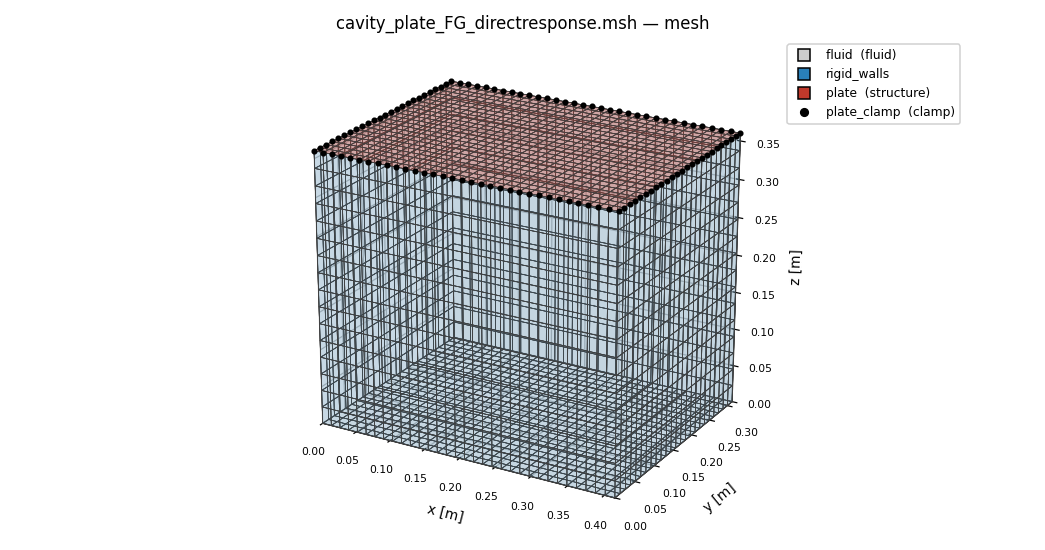

<Axes3D: title={'center': 'cavity_plate_FG_directresponse.msh — mesh'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [2]:
geometry = MeshFile(os.path.join("..", "Library",
                                 "cavity_plate_FG_directresponse.msh"))
picked = os.path.abspath(str(geometry.path))
print(type(geometry).__name__, "->", os.path.basename(picked))

nodes, elements, boundaries, groups = load_mesh_with_groups(picked,
                                                            verbose=False)
for name, group in sorted(groups.items(), key=lambda kv: -kv[1]["dim"]):
    kind = {3: "volume", 2: "surface", 1: "edge"}.get(group["dim"], "?")
    print(f"  {kind:<8} {name:<14} {len(group['nodes']):5d} nodes")

# What this mesh can carry, measured on the elements it already has.
LIMITS = frequency_limits(picked)
if LIMITS is not None:
    print(f"\nlargest fluid element {LIMITS['h_max'] * 1e3:.1f} mm in air: "
          f"good to ~1% up to {LIMITS['f_1pct']:.0f} Hz")
print(f"plate bending wavelength at {F_MAX:.0f} Hz: "
      f"{STRUCTURE.bending_wavelength(F_MAX) * 1e3:.0f} mm, against "
      f"{FLUID.wavelength(F_MAX) * 1e3:.0f} mm of sound")

plot_mesh_3d(nodes, groups, title=f"{os.path.basename(picked)} — mesh")

---
## 3. The model

`build_model` reads the mesh, checks it against `f_max`, draws it by role and
assembles both domains plus the coupling. The line to read is *interface
conforming*: plate quadrilaterals are the top faces of the fluid hexahedra,
so the coupling is assembled face by face with nothing interpolated.

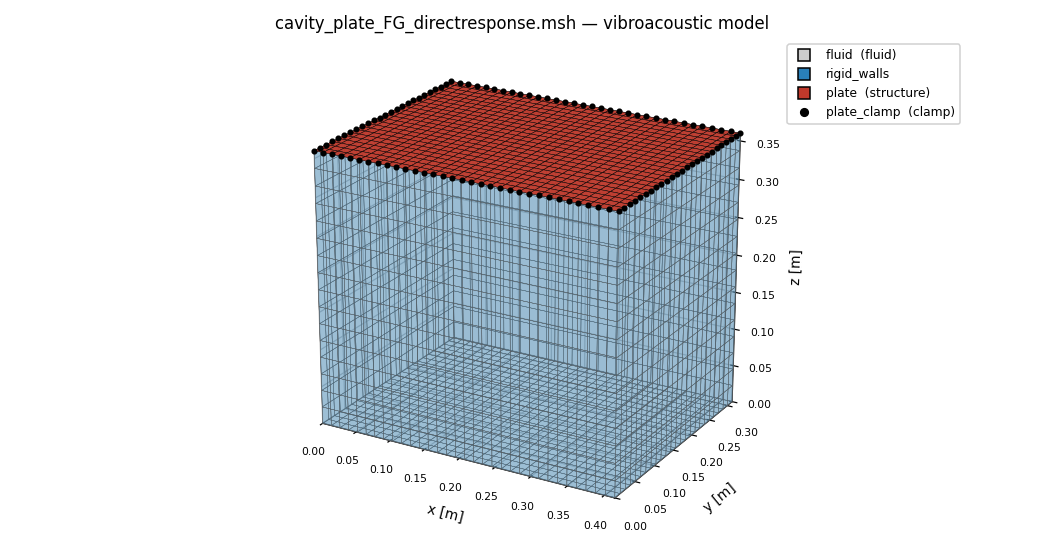

../Library/cavity_plate_FG_directresponse.msh  (vibroacoustic analysis)
-----------------------------------------------------------------------
  14025 nodes, 112 x Line 2, 3328 x Quadrilateral 4, 12288 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 768 faces, one fluid element behind each
  · fluid element size: 22.5 / 22.5 / 22.5 mm (min / mean / max)
  · good to ~1% up to 1173 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 1000 Hz: 15.2 elements per wavelength, dispersion error ~0.71%
  · selectable boundaries: rigid_walls
  => usable
domains in cavity_plate_FG_directresponse.msh (vibroacoustic analysis)
  fluid       group 'fluid'          <- air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure   group 'plate'          <- aluminium: t = 1.00 mm, E = 71 GPa, nu = 0.33, rho = 2700.0 kg/m3
  support     group 'plate_clamp'    <- clamped (the mesh says which nodes are held, Structure.support says how)
  selectable bo

In [3]:
spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,
    fluid=FLUID,
    structure=STRUCTURE,
    f_max=F_MAX,
    work_dir=".",
)
model = build_model(spec)

nodes = model["nodes"]
elements = model["elements"]
groups = model["groups"]
boundaries = model["boundaries"]
system = model["system"]
report = model["report"]

print(report)
print(describe_domains(report, FLUID, STRUCTURE))

# Where the plate is and how its nodes are laid out: measured, not assumed.
panel = describe_panel(nodes, groups[report.roles["structure"]]["nodes"])
fluid_nodes0 = np.asarray(groups[report.roles["fluid"]]["nodes"], dtype=int) - 1
BOX = [np.unique(np.round(nodes[:, i], 9)) for i in range(3)]
LX, LY, LZ = (a[-1] - a[0] for a in BOX)

print(f"\nplate      {panel}")
print(f"           elements {panel.spacing[0] * 1e3:.1f} x "
      f"{panel.spacing[1] * 1e3:.1f} mm, "
      f"{STRUCTURE.bending_wavelength(F_MAX) / max(panel.spacing):.1f} across "
      f"a bending wavelength at {F_MAX:.0f} Hz")
print(f"cavity     {LX:.3f} x {LY:.3f} x {LZ:.3f} m"
      f"   (Fahy & Gardonio: 0.414 x 0.314 x 0.360 m)")
print(f"unknowns   {system['structural']['idx_free'].size} structural + "
      f"{system['acoustic']['nodes0'].size} acoustic")

---
## 4. Where the peaks should be

Fifty coupled modes, computed once, to mark the lines the sweep should show.
They are undamped: they say where the peaks are, not how tall.

The 0 Hz uniform pressure of the sealed box is a genuine solution and stays
in the model — it is the air spring the plate works against — but it is not
a resonance, so it is left out of the lines drawn below.

In [4]:
blocks_free = build_coupled_blocks(system)     # hard walls: nothing is added

t0 = time.time()
f_modal, coupled_shapes = solve_vibroacoustic_modal(system, num_modes=N_MODES,
                                                    blocks=blocks_free)
resonances = f_modal[f_modal > 1.0]
inside = resonances[resonances <= F_MAX]

print(f"{f_modal.size} coupled modes in {time.time() - t0:.1f} s, "
      f"{blocks_free['n_s']} structural + {blocks_free['n_a']} acoustic "
      "unknowns")
print(f"{inside.size} of them inside the sweep, from {inside[0]:.1f} to "
      f"{inside[-1]:.1f} Hz; the basis reaches {f_modal[-1]:.0f} Hz")
for row in range(0, inside.size, 6):
    print("  " + "  ".join(f"{f:8.1f}" for f in inside[row:row + 6]))

50 coupled modes in 2.2 s, 4278 structural + 14025 acoustic unknowns
39 of them inside the sweep, from 82.9 to 995.3 Hz; the basis reaches 1154 Hz
      82.9     121.6     169.7     206.1     216.0     294.8
     319.8     322.0     365.1     406.5     418.4     441.5
     464.7     487.3     524.3     547.5     550.1     556.8
     572.0     630.2     646.6     655.0     686.8     692.0
     729.6     731.1     752.6     794.8     830.3     839.0
     839.1     864.6     868.9     891.7     911.5     944.8
     961.6     962.9     995.3


---
## 5. What drives it: 1 N at the centre

`structural_point_load` turns "one newton on that node along the normal" into
a vector on the free structural DOFs — a search in `idx_free` first, since
the clamped rim has no DOF to push.

The centre is a strong place and a blind one: a mode with a nodal line
through the middle is pushed exactly on its node and stays out of the
response. The table reads that off the coupled modes, as the displacement at
the drive relative to each mode's own peak. Those near zero are the modes
section 8 will not find.

In [5]:
structural_nodes0 = np.unique(system["structural"]["idx_free"] // 6)
centre = panel.centre()
DRIVE_NODE = int(structural_nodes0[np.argmin(
    np.linalg.norm(nodes[structural_nodes0] - centre, axis=1))])
F_s, dof = structural_point_load(system, DRIVE_NODE, FORCE, panel.normal)

print(f"drive      node {DRIVE_NODE} at "
      f"{np.round(nodes[DRIVE_NODE], 4)} m, {FORCE:.0f} N along "
      f"{'xyz'[panel.normal]}")
print(f"           the centre of the plate is at {np.round(centre, 4)} m, "
      f"{np.linalg.norm(nodes[DRIVE_NODE] - centre) * 1e3:.1f} mm away")

# How much each coupled mode moves at the drive point, against its own peak.
# Only the out-of-plane translations are compared: a shell node also carries
# rotations, and radians against metres would set the scale of a ratio that
# then says nothing about the shape.
n_s = blocks_free["n_s"]
idx_s = np.asarray(system["structural"]["idx_free"], dtype=int)
normal_rows = np.where(idx_s % 6 == panel.normal)[0]
w_modes = np.real(coupled_shapes[:n_s])
at_drive = (np.abs(w_modes[dof])
            / np.maximum(np.abs(w_modes[normal_rows]).max(axis=0), 1e-30))

flexible = np.where((f_modal > 1.0) & (f_modal <= F_MAX))[0]
driven = [i for i in flexible if at_drive[i] >= 0.05]
blind = [i for i in flexible if at_drive[i] < 0.05]

print(f"\n{len(driven)} of the {flexible.size} modes inside the sweep move at "
      f"the drive point;\n{len(blind)} are nodal there and no force at the "
      "centre can reach them")
print(f"\n  {'f [Hz]':>9} {'w(drive) / w(peak)':>20}")
for i in flexible:
    print(f"  {f_modal[i]:9.1f} {at_drive[i]:20.2f}"
          + ("" if at_drive[i] >= 0.05 else "   nodal at the drive"))

drive      node 1353 at [0.207 0.157 0.36 ] m, 1 N along z
           the centre of the plate is at [0.207 0.157 0.36 ] m, 0.0 mm away

13 of the 39 modes inside the sweep move at the drive point;
26 are nodal there and no force at the centre can reach them

     f [Hz]   w(drive) / w(peak)
       82.9                 1.00
      121.6                 0.00   nodal at the drive
      169.7                 0.00   nodal at the drive
      206.1                 0.93
      216.0                 0.00   nodal at the drive
      294.8                 0.00   nodal at the drive
      319.8                 0.00   nodal at the drive
      322.0                 0.96
      365.1                 0.00   nodal at the drive
      406.5                 0.00   nodal at the drive
      418.4                 0.00   nodal at the drive
      441.5                 0.98
      464.7                 0.88
      487.3                 1.00
      524.3                 0.00   nodal at the drive
      547.5             

---
## 6. Ten direct lines

The coupled system solved as it stands: nothing projected, nothing
truncated, the answer is the mesh's. The price is one factorization per
frequency — 3.3 s here — so the whole 491-line grid is nearly half an hour
and this notebook runs **ten lines** of it instead.

Which ten is the whole point. Five sit on coupled resonances the centred
force can actually reach (section 5 named them), five halfway between
consecutive modes, and all ten are snapped to the `DF` grid so that the
reduced models of section 7 are read at exactly the same frequencies. A peak
is where a truncated basis is worst and a floor is where it is best; ten
lines split that way say more than ten spread evenly.

Only the plate is damped. The air carries no loss and the walls are hard.

Three microphones are picked as well — a corner (antinode of every cavity
mode), the middle of the cavity, the floor under the drive point — not as
curves but as the places marked on the field picture of section 8b.


In [6]:
blocks = build_coupled_blocks(system, eta_s=ETA_S)   # the damped run

# The microphones, as the nearest fluid node to each place asked for.
WANTED = {"corner": (0.0, 0.0, 0.0),
          "cavity centre": (LX / 2, LY / 2, LZ / 2),
          "floor under the drive": (centre[0], centre[1], 0.0)}
MICS = {}
for name, xyz in WANTED.items():
    node0 = int(fluid_nodes0[np.argmin(
        np.linalg.norm(nodes[fluid_nodes0] - xyz, axis=1))])
    MICS[name] = (node0, nodes[node0])
    print(f"  {name:<22} node {node0:6d} at {np.round(nodes[node0], 3)} m")

# Half the lines on resonances the drive reaches, half between modes.
on_peak = f_modal[driven]
pick = np.unique(np.linspace(0, on_peak.size - 1, N_PROBE // 2).round()
                 ).astype(int)
on_peak = on_peak[pick]
between = 0.5 * (inside[:-1] + inside[1:])
pick = np.unique(np.linspace(0, between.size - 1, N_PROBE - on_peak.size
                             ).round()).astype(int)
off_peak = between[pick]

# Snapped to the grid the reduced models are swept on, so that the two are
# compared at the same frequency and not across a step.
probe = np.concatenate([on_peak, off_peak])
probe = F_MIN + np.round((probe - F_MIN) / DF) * DF
f_probe = np.unique(probe[(probe >= F_MIN) & (probe <= F_MAX)])
is_peak = np.isin(f_probe, F_MIN + np.round((on_peak - F_MIN) / DF) * DF)

print(f"\n{f_probe.size} direct lines, "
      f"{is_peak.sum()} on a mode the drive reaches, {(~is_peak).sum()} between:")
for f, on in zip(f_probe, is_peak):
    near = inside[int(np.argmin(np.abs(inside - f)))]
    print(f"  {f:7.1f} Hz   {'on' if on else 'between'} "
          f"({'mode at ' if on else 'nearest mode '}{near:.1f} Hz)")

t0 = time.time()
direct = solve_vibroacoustic_frequency_sweep(system, f_probe, F_s=F_s,
                                             blocks=blocks, verbose=True)
w_direct, p_direct = direct["w"], direct["p"]
w_drive_direct = w_direct[dof]
t_direct = time.time() - t0

# The cavity average at these ten lines, as section 8 reads it off the
# reduced curves: straight off the acoustic mass matrix.
Ma = blocks["Ma"]
p_rms_direct = np.sqrt(np.maximum(
    np.einsum("ij,ij->j", p_direct.conj(), Ma @ p_direct).real
    / Ma.sum() / 2.0, 0.0))          # /2: amplitude to mean square

print(f"\n{f_probe.size} lines in {t_direct:.1f} s, "
      f"{blocks['n_s'] + blocks['n_a']} unknowns, "
      f"{t_direct / f_probe.size:.2f} s per line "
      f"(the full {frequencies.size}-line grid would be "
      f"~{t_direct / f_probe.size * frequencies.size / 60:.0f} min)")


  corner                 node      0 at [0. 0. 0.] m
  cavity centre          node   8677 at [0.207 0.157 0.18 ] m
  floor under the drive  node    640 at [0.207 0.157 0.   ] m

10 direct lines, 5 on a mode the drive reaches, 5 between:
     82.0 Hz   on (mode at 82.9 Hz)
    102.0 Hz   between (nearest mode 82.9 Hz)
    412.0 Hz   between (nearest mode 406.5 Hz)
    442.0 Hz   on (mode at 441.5 Hz)
    602.0 Hz   between (nearest mode 630.2 Hz)
    692.0 Hz   on (mode at 692.0 Hz)
    834.0 Hz   between (nearest mode 830.3 Hz)
    864.0 Hz   on (mode at 864.6 Hz)
    962.0 Hz   on (mode at 961.6 Hz)
    980.0 Hz   between (nearest mode 995.3 Hz)


  [1/10] f =    82.00 Hz  |w|max = 2.338e-02  |p|max = 2.721e+02


  [2/10] f =   102.00 Hz  |w|max = 1.132e-03  |p|max = 1.529e+01


  [3/10] f =   412.00 Hz  |w|max = 5.827e-04  |p|max = 7.419e+00


  [4/10] f =   442.00 Hz  |w|max = 2.912e-03  |p|max = 4.083e+01


...

  [6/10] f =   692.00 Hz  |w|max = 1.439e-03  |p|max = 2.042e+01


  [7/10] f =   834.00 Hz  |w|max = 3.630e-04  |p|max = 2.832e+01


  [8/10] f =   864.00 Hz  |w|max = 1.303e-03  |p|max = 3.204e+01


  [9/10] f =   962.00 Hz  |w|max = 1.326e-03  |p|max = 8.229e+02


  [10/10] f =   980.00 Hz  |w|max = 1.944e-04  |p|max = 1.969e+01

10 lines in 32.7 s, 18303 unknowns, 3.27 s per line (the full 491-line grid would be ~27 min)


---
## 7. The two reduced models, across the band

Both expand the response on a small basis and solve an `m x m` system per
line instead of an 18 000 x 18 000 one — the whole grid in seconds. Same
number of vectors for both, so what differs is the basis and not its length.

* **Coupled modes** (`build_coupled_modal_basis`) — modes of the whole
  vibroacoustic system. Expensive to build (one large unsymmetric
  eigenproblem) and the most efficient per vector: the coupling is already
  inside each mode.
* **CMS** (`build_cms_basis`) — plate *in vacuo* plus the sealed hard-walled
  cavity, two symmetric eigenproblems, coupling put back only in the reduced
  matrices. Cheap to build, less efficient: hard-wall modes reconstruct the
  field next to a moving plate slowly.

These are the curves everything below is drawn from. What they are worth is
settled in section 10, against the ten direct lines.


In [7]:
# Same basis size for both: 2 x f_max is the usual truncation rule.
M_S, M_A = 60, 120                 # CMS: plate modes + hard-wall cavity modes
M_C = M_S + M_A                    # coupled modes, the same count

builders = {
    "coupled": lambda: build_coupled_modal_basis(blocks=blocks_free,
                                                 num_modes=M_C),
    "CMS":     lambda: build_cms_basis(blocks=blocks_free,
                                       num_structural=M_S, num_acoustic=M_A),
}

REDUCED = {}
for label, build in builders.items():
    t0 = time.time()
    basis = build()
    t_build = time.time() - t0

    t0 = time.time()
    out = solve_coupled_modal_frequency_sweep(basis, frequencies, F_s=F_s,
                                              eta_s=ETA_S)
    t_sweep = time.time() - t0

    p_r = out["p"]
    REDUCED[label] = {
        "w": out["w"][dof],
        "p_rms": np.sqrt(np.maximum(
            np.einsum("ij,ij->j", p_r.conj(), Ma @ p_r).real
            / Ma.sum() / 2.0, 0.0)),
        "t_build": t_build,
        "t_sweep": t_sweep,
        "m": basis["Phi_R"].shape[1],
        "f_top": float(basis["freqs"].max()),
    }
    if label == "coupled":
        p_coupled = p_r                    # kept for the picture in 8b
    print(f"{label:<8} {REDUCED[label]['m']:4d} vectors reaching "
          f"{REDUCED[label]['f_top']:6.0f} Hz, "
          f"basis {t_build:6.1f} s + sweep {t_sweep:5.1f} s for "
          f"{frequencies.size} lines, against "
          f"~{t_direct / f_probe.size * frequencies.size / 60:.0f} min direct")


coupled   180 vectors reaching   2508 Hz, basis    5.2 s + sweep   0.4 s for 491 lines, against ~27 min direct


CMS       180 vectors reaching   2580 Hz, basis    3.2 s + sweep   0.4 s for 491 lines, against ~27 min direct


---
## 8. Reading it: the two reduced models against the ten direct lines

Two quantities, one panel each, never two scales on one frame: the plate at
the drive point, a receptance in m/N, and the whole cavity, the
volume-averaged pressure the acoustic mass matrix gives for nothing. The
average is what a coupled run is usually asked for, and unlike a microphone
it cannot sit on a node.

The **lines are the two reduced models** across the band, the **dots the ten
direct lines** of section 6. Read them where the dots are and nowhere else:
that is all the direct solve was asked. Grey lines are the modes of section 4.

The table under the curves is what the reduction is bought with — the basis,
the sweep, and what the same 491 lines would have cost the direct solver at
the rate section 6 measured.


read off the coupled-modal curves:
peak |w| at the drive     2.410 mm/N at 82 Hz
loudest cavity average    141.9 dB re 20 uPa at 962 Hz
most power into the plate 347.96 mW at 82 Hz

method          basis [s]  sweep [s]   lines  per line [s]    491 lines   speed-up
direct                  -       32.7      10          3.27        27 min         1x
coupled               5.2        0.4     491        0.0114       5.6 s         286x
CMS                   3.2        0.4     491        0.0074       3.6 s         443x


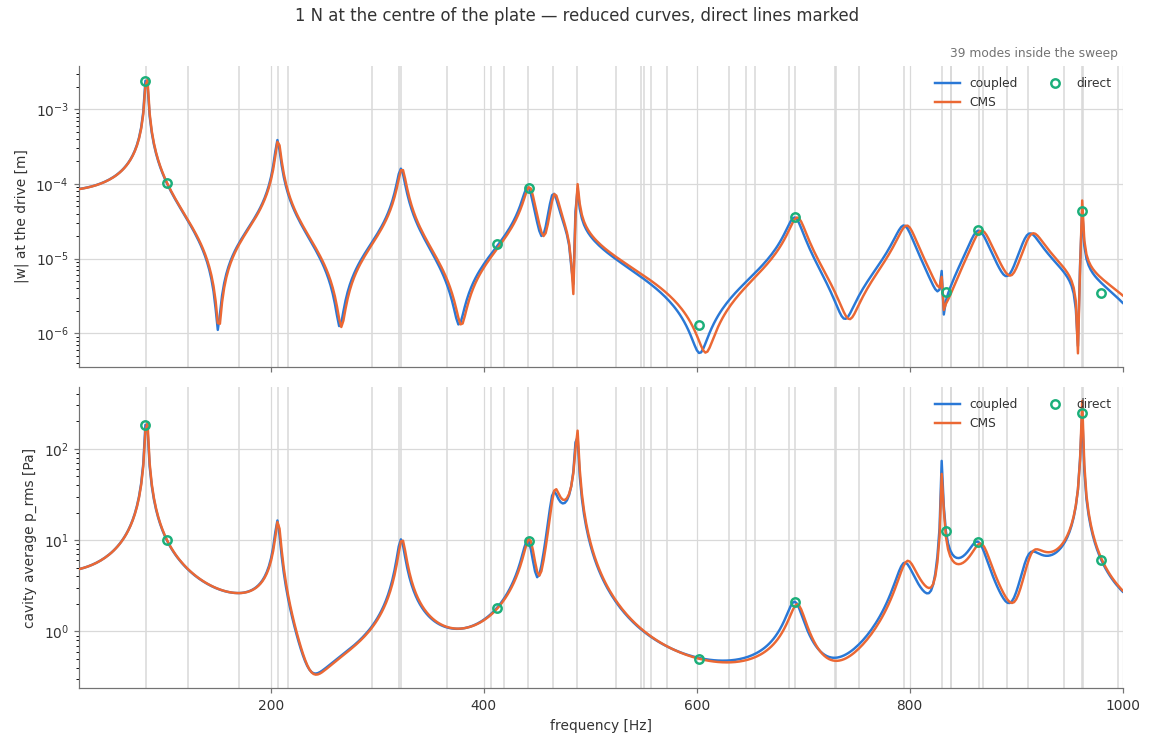

[<Axes: ylabel='|w| at the drive [m]'>,
 <Axes: xlabel='frequency [Hz]', ylabel='cavity average p_rms [Pa]'>]

In [8]:
w_drive = REDUCED["coupled"]["w"]            # the curves read below
p_rms = REDUCED["coupled"]["p_rms"]
spl = 20 * np.log10(np.maximum(p_rms, 1e-12) / 2e-5)

# Power the force puts into the plate: half the real part of F times the
# conjugate velocity, and the velocity is j omega w.
velocity = 1j * 2 * np.pi * frequencies * w_drive
power_in = 0.5 * np.real(FORCE * np.conj(velocity))

print("read off the coupled-modal curves:")
print(f"peak |w| at the drive     {np.abs(w_drive).max() * 1e3:.3f} mm/N at "
      f"{frequencies[np.argmax(np.abs(w_drive))]:.0f} Hz")
print(f"loudest cavity average    {spl.max():.1f} dB re 20 uPa at "
      f"{frequencies[np.argmax(spl)]:.0f} Hz")
print(f"most power into the plate {power_in.max() * 1e3:.2f} mW at "
      f"{frequencies[np.argmax(power_in)]:.0f} Hz")

# What each method cost, and what the direct solver would have cost on the
# whole grid at the rate it was measured at.
per_line = t_direct / f_probe.size
direct_grid = per_line * frequencies.size

print(f"\n{'method':<14} {'basis [s]':>10} {'sweep [s]':>10} {'lines':>7}"
      f" {'per line [s]':>13} {'491 lines':>12} {'speed-up':>10}")
print(f"{'direct':<14} {'-':>10} {t_direct:10.1f} {f_probe.size:7d}"
      f" {per_line:13.2f} {direct_grid / 60:9.0f} min {'1x':>10}")
for label, run in REDUCED.items():
    total = run["t_build"] + run["t_sweep"]
    print(f"{label:<14} {run['t_build']:10.1f} {run['t_sweep']:10.1f} "
          f"{frequencies.size:7d} {total / frequencies.size:13.4f} "
          f"{total:9.1f} s   {direct_grid / total:9.0f}x")

plot_frf(frequencies,
         {"|w| at the drive [m]": {"coupled": w_drive,
                                   "CMS": REDUCED["CMS"]["w"]},
          "cavity average p_rms [Pa]": {"coupled": p_rms,
                                        "CMS": REDUCED["CMS"]["p_rms"]}},
         points={"|w| at the drive [m]": {"direct": (f_probe, w_drive_direct)},
                 "cavity average p_rms [Pa]": {"direct": (f_probe,
                                                          p_rms_direct)}},
         resonances=inside,
         title=f"{FORCE:.0f} N at the centre of the plate — reduced curves, "
               "direct lines marked",
         show=True)


### 8b. The field at the loudest line

One picture, at the frequency where the cavity average is highest, with the
three microphone positions marked on it. A magnitude, so a single hue. The
field is the coupled-modal one: at 491 lines the direct solve has no say in
where the loudest of them is.


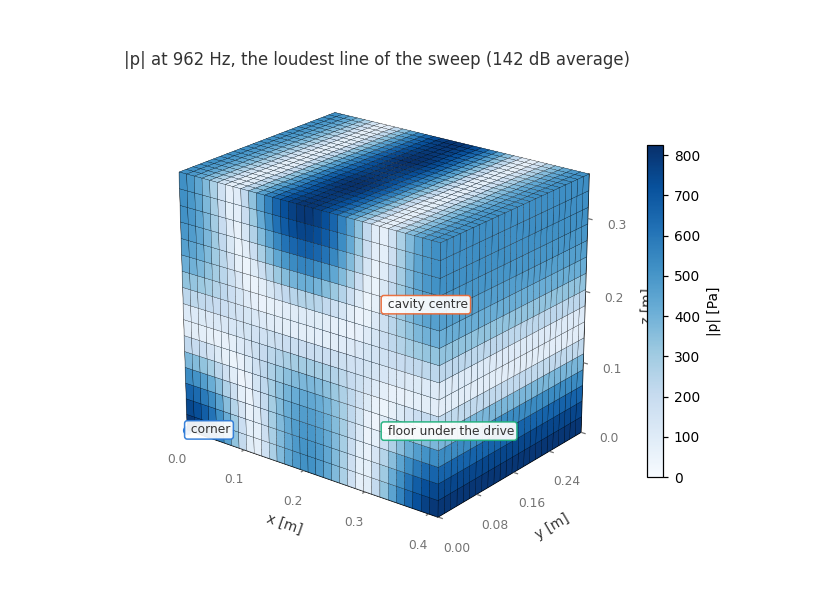

<Axes3D: title={'center': '|p| at 962 Hz, the loudest line of the sweep (142 dB average)'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [9]:
loudest = int(np.argmax(spl))
p_loudest = expand_pressure(p_coupled[:, [loudest]], blocks["idx_a"],
                            nodes.shape[0])[:, 0]
plot_field(nodes, elements, p_loudest, part="abs", show=True,
           markers={name: xyz for name, (_, xyz) in MICS.items()},
           title=f"|p| at {frequencies[loudest]:.0f} Hz, the loudest line "
                 f"of the sweep ({spl[loudest]:.0f} dB average)")


---
## What to take away

* **The mesh is part of the frequency.** 02's coarse mesh answers eighteen
  modes and nothing above; 1000 Hz needs the plate cut for its bending
  wavelength, which is what fixes 32 x 24 x 16 here.
* **A direct sweep has no basis to be wrong about** — one factorization per
  line, and that is the whole of what it costs. At about 3 s a line it is
  priced out of a 491-line band, which is why it is run at ten lines here and
  the band is drawn by the reduced models.
* **Spend the direct lines where they say something.** On the peaks a
  truncated basis is at its worst and between the modes at its best; ten
  lines split that way bound the reduction, ten spread evenly flatter it.
* **Both reductions buy the same thing at different prices.** Coupled modes
  cost a large unsymmetric eigenproblem and sit on the direct dots best per
  vector; CMS costs two symmetric ones and needs more vectors for the same
  accuracy near the plate. The table in section 8 is the price of each.
* **Where the force is decides what answers.** At the centre, every mode with
  a nodal line through the middle is pushed on its node: section 5 names
  them, and the curves carry no peak there.
* **Damp what you claim to have damped.** eta_s is the plate's; the air and
  the walls carry none.
* **Read the cavity, not one node of it.** The space average cannot sit on a
  nodal surface the way a microphone can.

The modes of this box against Fahy & Gardonio's table are in
`02_cavity_plate_coupled_FG.ipynb`. A run on any geometry, boundaries and
drive asked rather than pinned, is `03_any_geometry_any_analysis.ipynb`.
